Problem statement:
A shopping mall collects data of its customers- age, gender, annual income, and assigns spending score.

The marketing team wants to perform a targetted marketing but does not have a predefined customer categories. (because there are no labels to predict)

Build a kmeans algorithm to segment the customer into meaningful groups/clusters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('/content/sample_data/Mall_Customers.csv')

In [4]:
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [9]:
## drop unnecassary columns
df.drop(['CustomerID'],axis=1,inplace=True)

In [11]:
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
## Gender distribution: univariate analysis

df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


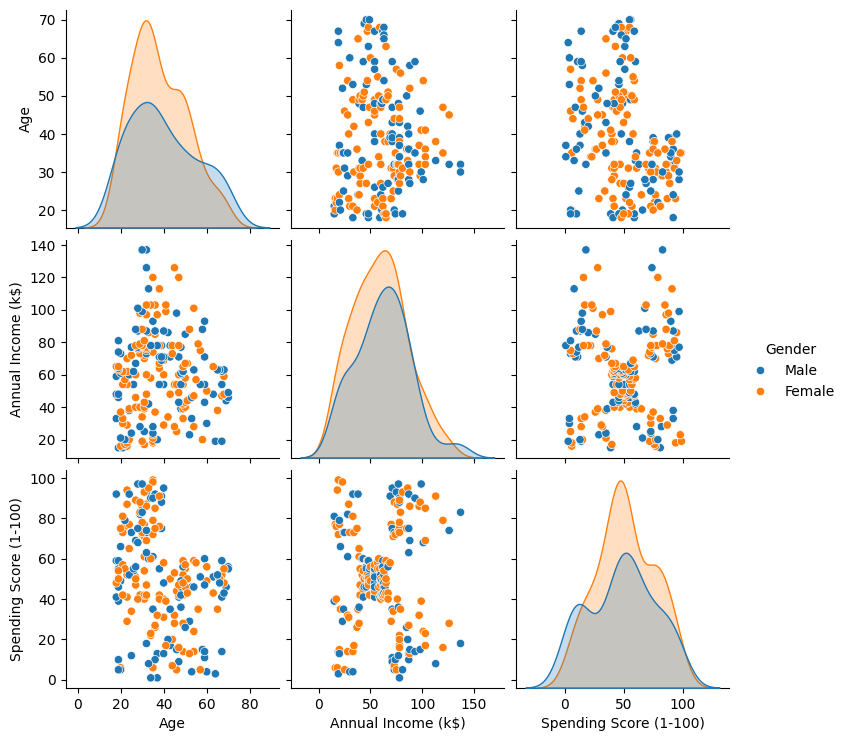

In [14]:
## pair plot of spending score vs gender/ income/ age

sns.pairplot(df, hue='Gender')

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [16]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [18]:
km = KMeans()

In [19]:
km.fit(X)

KMeans()

In [20]:
## we will find out SSE for the above build model

km.inertia_

25028.020475269397

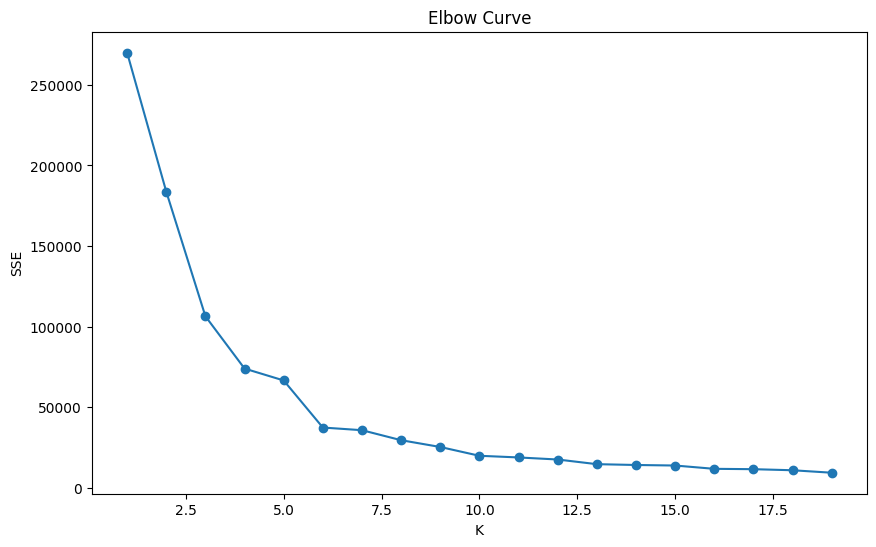

In [21]:
## Run this for a range 1-20 and find the optimal value of K

sse = []

for k in range(1,20):
  km = KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)


plt.figure(figsize=(10,6))
plt.plot(range(1,20), sse, marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Curve')
plt.show()

In [22]:
optimal_value = 5

km = KMeans(n_clusters=optimal_value)
km.fit(X)

KMeans(n_clusters=5)

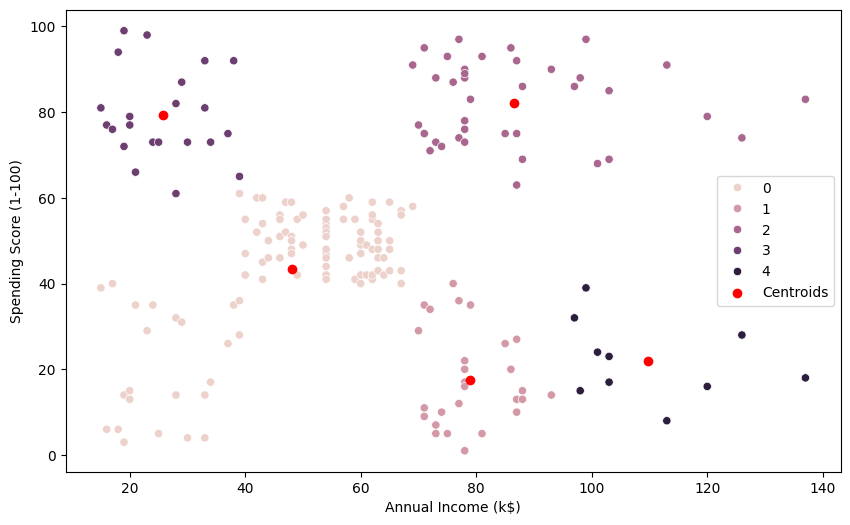

In [23]:
## Visualize the clusters

centroids = km.cluster_centers_

plt.figure(figsize=(10,6))
sns.scatterplot(data=X, x='Annual Income (k$)', y='Spending Score (1-100)', hue=km.labels_)
plt.scatter(centroids[:,0], centroids[:,1], c='red', label='Centroids')
plt.legend()
plt.show()